# RQ1: Can AI accurately predict bike-sharing demand?

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.4 MB/s eta 0:01:15
    --------------------------------------- 1.3/101.7 MB 1.8 MB/s eta 0:00:57
    --------------------------------------- 1.8/101.7 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 2.6/101.7 MB 2.3 MB/s eta 0:00:43
   - -------------------------------------- 3.1/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.7/101.7 MB 2.4 MB/s eta 0:00:42
   - -------------------------------------- 4.2/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 4.7/101.7 MB 2.4 MB/s eta 0:00:41
   -- ------------------------------------- 5.2/101.7 MB 2.5 MB/s eta 0:00:40
   -- ------------------------------------- 6.0/101.7 MB 2.5 MB/s eta 0:00:38
   -- -

In [4]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.1 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import shap

# Load dataset
df = pd.read_csv(r'C:\Users\Admin\Downloads\SeoulBikeData.csv', encoding='latin1')

# Basic preprocessing
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

encoder = LabelEncoder()

categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

X = df.drop(['Date', 'Rented Bike Count'], axis=1)
y = df['Rented Bike Count']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [3]:

# Train models

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2 Score']
)

results_df.to_csv('table1_model_performance.csv', index=False)

print(results_df)


               Model         MAE        RMSE  R2 Score
0  Linear Regression  330.103087  440.293401  0.534717
1      Decision Tree  131.425228  254.145013  0.844977
2      Random Forest   98.584720  174.309698  0.927075
3            XGBoost   98.808945  168.272914  0.932039


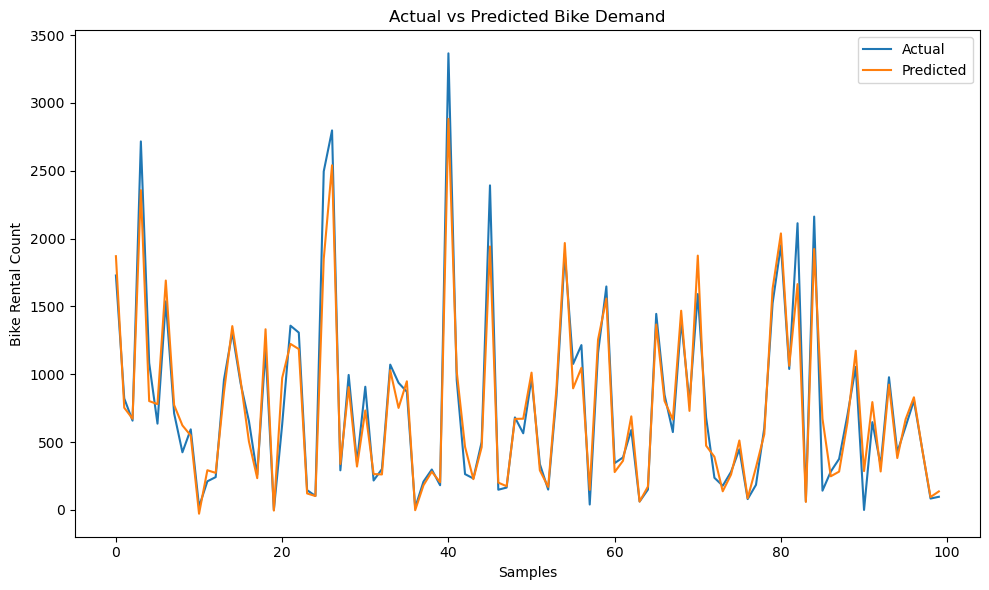

In [4]:

# Generate publication-ready figure

best_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label='Actual')

plt.plot(predictions[:100], label='Predicted')

plt.title('Actual vs Predicted Bike Demand')

plt.xlabel('Samples')

plt.ylabel('Bike Rental Count')

plt.legend()

plt.tight_layout()

plt.savefig(
    'figure1_actual_vs_predicted.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure1_actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
